1. Data Import and Cleaning:

Import the dataset using Pandas.

Clean and preprocess the data, addressing missing values and categorizing data as needed.

Convert dates and other relevant fields to appropriate formats.

In [1]:
# Libraries for data analysis, statistics and visualization
import pandas as pd
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load CSV file into a DataFrame; encoding set to latin1 to handle special characters
data = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin1')

In [3]:
# Show a random sample of 10 rows to inspect the data
data.sample(10)

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
4759,8/24/2010,7:30,"Bastipur, Nepal",Agni Air,101,Kathmandu - Lukla,Dornier 228-101,9NAHE,732,14.0,11.0,3.0,14.0,11.0,3.0,0.0,The crew decided to divert to Simara Airport d...
4603,3/11/2007,23:20,"Hanea, Kauai, Hawaii",Inter-Island,NaN,NaN,Mc Donnell Douglas 369FF Rotocraft,N911VC,0049FF,5.0,4.0,1.0,1.0,1.0,0.0,0.0,The helicopter was flying low near the coast w...
1367,2/9/1953,19:00,"Cairo, Egypt",Military - Egyptian Air Force,NaN,Al Arish - Cairo,Curtiss-Wright C-46,1001,NaN,40.0,35.0,5.0,29.0,24.0,5.0,0.0,Crashed into a hill during a sandstorm 50 km n...
229,9/11/1930,NaN,"Croydon, England",Sabena,NaN,Croydon - Brussels,Sabca F-VII,OO-AIN,NaN,2.0,0.0,2.0,2.0,0.0,2.0,0.0,The plane caught on file shortly after taking ...
3845,12/1/1993,19:50,"Hibbing, Minnesota",Express Airlines - Northwest Airlink,5719,Minneapolis/St. Paul - Hibbing,British Aerospace Jetstream BA-3100,N334PX,706,18.0,16.0,2.0,18.0,16.0,2.0,0.0,"While on approach, the aircraft collided with ..."
2039,7/13/1963,5:06,"Near Irkutsk, Russia",Aeroflot,12,Moscow - Irkutsk,Tupolev TU-104B,CCCP42492,21605,32.0,24.0,8.0,32.0,24.0,8.0,0.0,Crashed 2 miles short of the runway during app...
4943,2/10/2018,17:31,"Grand Canyon, Arizona",Papillon,NaN,Sightseeing,Eurocopter EC 130B4,N155GC,7091,7.0,6.0,1.0,3.0,3.0,0.0,0.0,The helicopter was observed making strange man...
1094,2/4/1949,NaN,"Castel Benito, Libya",Skyways of London,NaN,Khartoum - Castel Benito,Douglas C-54A-1-DO Skymaster,G-AJPL,7464,53.0,44.0,9.0,1.0,0.0,1.0,0.0,"The No. 4, followed by the No. 3 engines faile..."
3598,12/30/1989,NaN,Milford Sound,Air Fiordland,NaN,NaN,Cessna 207 / Cessna 207,ZK-DAX / ZK-DQF,131/53,5.0,4.0,1.0,5.0,4.0,1.0,0.0,"Midair collision. Five killed on ZA-DAX, ZK-DQ..."
1342,10/16/1952,NaN,"Off Kangnung, South Korea",Military - U.S. Air Force,NaN,NaN,Curtiss-Wright C-46D-CU,44-77538,32934,25.0,21.0,4.0,25.0,21.0,4.0,0.0,The aircraft crashed into the Sea of Japan whi...


In [4]:
# Show DataFrame info: dtypes and non-null counts
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   str    
 1   Time                   3486 non-null   str    
 2   Location               4994 non-null   str    
 3   Operator               4988 non-null   str    
 4   Flight #               1329 non-null   str    
 5   Route                  4221 non-null   str    
 6   AC Type                4983 non-null   str    
 7   Registration           4724 non-null   str    
 8   cn/ln                  4330 non-null   str    
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Ground         

In [5]:
# Descriptive statistics for numeric columns
data.describe()

,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground
count,4980.000000,4769.000000,4772.000000,4990.000000,4756.000000,4757.000000,4956.000000
mean,31.195984,27.009017,4.479254,22.373547,19.053827,3.578516,1.719128
std,45.534788,44.111609,3.483859,35.061741,34.146127,3.167922,55.540273
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,3.000000,2.000000,4.000000,1.000000,2.000000,0.000000
50%,16.000000,12.000000,4.000000,11.000000,8.000000,3.000000,0.000000
75%,35.000000,30.000000,6.000000,25.000000,21.000000,5.000000,0.000000
max,644.000000,614.000000,61.000000,583.000000,560.000000,46.000000,2750.000000


In [6]:
# Count duplicated rows in the DataFrame
data.duplicated().sum()

np.int64(0)

In [7]:
# Compute missing values and percentages per column
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Missing Percentage
Time,1512,30.252101
Location,4,0.080032
Operator,10,0.200080
Flight #,3669,73.409364
Route,777,15.546218
AC Type,15,0.300120
Registration,274,5.482193
cn/ln,668,13.365346
Aboard,18,0.360144
Aboard Passangers,229,4.581833


In [8]:
# Drop the 'Flight #' column because it has ~73% missing values
data = data.drop(columns=["Flight #"])

In [9]:
# Drop rows missing values in critical text/numeric columns and report removed rows
cols_to_drop_rows = [
    "Location",
    "Operator",
    "AC Type",
    "Aboard",
    "Fatalities",
    "Ground",
    "Summary",
]

rows_before = len(data)

data = data.dropna(subset=cols_to_drop_rows)

rows_after = len(data)
rows_removed = rows_before - rows_after
percentage_removed = rows_removed / rows_before * 100

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_removed)
print("Percentage removed:", round(percentage_removed, 2), "%")

Rows before: 4998
Rows after: 4876
Rows removed: 122
Percentage removed: 2.44 %


In [10]:
# Recompute missing values after dropping rows/columns
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Missing Percentage
Time,1408,28.876128
Route,702,14.397047
Registration,229,4.696473
cn/ln,594,12.182116
Aboard Passangers,174,3.568499
Aboard Crew,171,3.506973
Fatalities Passangers,189,3.876128
Fatalities Crew,187,3.835111


In [11]:
# Fill text columns with a default label 'Unknown' to avoid nulls
text_cols = [
    "Time", "Location", "Operator", "Route", 
    "AC Type", "Registration", "cn/ln", "Summary"
]

data[text_cols] = data[text_cols].fillna("Unknown")

In [12]:
# Show a small sample to verify fills and drops
data.sample(5)

,Date,Time,Location,Operator,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
2650,2/19/1973,9:15,"Morgan City, Louisiana",Petrolium Helo Inc.,"Oil platform - Morgan City, LA",Bell 206B,N14831,Unknown,5.0,4.0,1.0,5.0,4.0,1.0,0.0,Crashed after the failure of the main rotor. ...
3349,1/21/1986,4:25,"Ellendale, Minnesota",Air Taxi,Unknown,Bell 296B,N1498W,425,3.0,2.0,1.0,3.0,2.0,1.0,0.0,The purpose of the flight was to take a news c...
3048,1/11/1980,1:23,Over the Atlantic Ocean,Private charter,Shreveport - Baton Rouge,Cessna 441 Conquest,N442NC,Unknown,2.0,1.0,1.0,2.0,1.0,1.0,0.0,The plane was on a 45 minute fight from Shreve...
604,3/1/1941,15:50,"Trontheim, Norway",Deutsche Lufthansa,Unknown,Junkers JU-52/3m,D-AQUB,5751,12.0,9.0,3.0,3.0,3.0,0.0,0.0,The seaplane crashed while attemping to land a...
3774,9/26/1992,18:00,"Near Lagos, Nigeria",Military - Federal Nigerian Air Force,Lagos - Kaduna,Lockheed C-130H,NAF911,4624,158.0,154.0,4.0,158.0,154.0,4.0,0.0,The aircraft attempted to ditch into a canal a...


In [13]:
# Recompute missing summary once more to confirm
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Missing Percentage
Aboard Passangers,174,3.568499
Aboard Crew,171,3.506973
Fatalities Passangers,189,3.876128
Fatalities Crew,187,3.835111


In [14]:
# Fill numeric count columns using the median to reduce bias from outliers
numeric_cols = [
    "Aboard Passangers", "Aboard Crew",
    "Fatalities Passangers", 
    "Fatalities Crew"
]

data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

In [15]:
# Confirm numeric fills by recomputing missing summary
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Missing Percentage


In [16]:
# Parse the 'Date' column into datetime objects; coerce invalid parses to NaT
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

In [17]:
# Extract year/month/day from parsed datetime for easier grouping and analysis
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
# data["Time"] = pd.to_datetime(data["Time"], format="%H:%M", errors="coerce").dt.time

In [18]:
# Example of parsing Time if needed; commented out because Time formats vary
# data["Time_Parsed"] = pd.to_datetime(
#     data["Time"],
#     format="%H:%M",
#     errors="coerce"
# ).dt.time

In [19]:
# Quick peek at Time parsing results (commented out)
# data[["Time", "Time_Parsed"]].head(20)

In [20]:
# Ensure count-related columns are integer type for accurate sums
count_cols = [
    "Aboard",
    "Aboard Passangers",
    "Aboard Crew",
    "Fatalities",
    "Fatalities Passangers",
    "Fatalities Crew",
    "Ground"
]

data[count_cols] = data[count_cols].astype(int)

In [21]:
# Check DataFrame info again after type conversions
data.info()

<class 'pandas.DataFrame'>
Index: 4876 entries, 0 to 4997
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   4876 non-null   datetime64[us]
 1   Time                   4876 non-null   str           
 2   Location               4876 non-null   str           
 3   Operator               4876 non-null   str           
 4   Route                  4876 non-null   str           
 5   AC Type                4876 non-null   str           
 6   Registration           4876 non-null   str           
 7   cn/ln                  4876 non-null   str           
 8   Aboard                 4876 non-null   int64         
 9   Aboard Passangers      4876 non-null   int64         
 10  Aboard Crew            4876 non-null   int64         
 11  Fatalities             4876 non-null   int64         
 12  Fatalities Passangers  4876 non-null   int64         
 13  Fatalities Crew    

2. Exploratory Data Analysis:

Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.

Analyze the frequency of crashes over time to identify any trends.

In [22]:
# Compute overall crash/fatality/ survival statistics
# Total number of crashes
total_crashes = len(data)

# Total fatalities
total_fatalities = data["Fatalities"].sum()

# Total people aboard
total_aboard = data["Aboard"].sum()

# Total survivors
total_survivors = total_aboard - total_fatalities

# Survival rate
survival_rate = (total_survivors / total_aboard) * 100

print("Total crashes:", total_crashes)
print("Total people aboard:", int(total_aboard))
print("Total fatalities:", int(total_fatalities))
print("Total survivors:", int(total_survivors))
print("Overall survival rate:", round(survival_rate, 2), "%")

Total crashes: 4876
Total people aboard: 154060
Total fatalities: 110423
Total survivors: 43637
Overall survival rate: 28.32 %


In [23]:
# Add per-row survivors and survival rate columns
data["Survivors"] = data["Aboard"] - data["Fatalities"]

data["Survival_Rate"] = data.apply(
    lambda row: ((row["Aboard"] - row["Fatalities"]) / row["Aboard"]) * 100
    if row["Aboard"] > 0 else None,
    axis=1
)

data[["Aboard", "Fatalities", "Survivors", "Survival_Rate"]].sample(5)

,Aboard,Fatalities,Survivors,Survival_Rate
1384,43,43,0,0.0
2377,5,1,4,80.0
72,1,1,0,0.0
4678,7,7,0,0.0
2320,18,18,0,0.0


In [24]:
# Show descriptive stats for the new survivor-related columns
data[["Aboard", "Fatalities", "Survivors", "Survival_Rate"]].describe()

,Aboard,Fatalities,Survivors,Survival_Rate
count,4876.000000,4876.000000,4876.000000,4871.000000
mean,31.595570,22.646226,8.949344,18.285612
std,45.900705,35.380118,30.955195,31.323302
min,0.000000,0.000000,0.000000,0.000000
25%,7.000000,4.000000,0.000000,0.000000
50%,17.000000,11.000000,0.000000,0.000000
75%,35.000000,25.000000,4.000000,25.000000
max,644.000000,583.000000,516.000000,100.000000


In [25]:
# Review the most fatal crashes in the dataset
data.sort_values("Fatalities", ascending=False)[
    ["Date", "Location", "Operator", "AC Type", "Aboard", "Fatalities", "Survivors"]
].head(5)

,Date,Location,Operator,AC Type,Aboard,Fatalities,Survivors
2885,1977-03-27,"Tenerife, Canary Islands",Pan American World Airways / KLM,Boeing B-747-121 / Boeing B-747-206B,644,583,61
3324,1985-08-12,"Mt. Osutaka, near Ueno Village, Japan",Japan Air Lines,Boeing B-747-SR46,524,520,4
4039,1996-11-12,"Near Charkhi Dadri, India",Saudi Arabian Airlines / Kazakhstan Airlines,Boeing B-747-168B / Ilyushin IL-76TD,349,349,0
2720,1974-03-03,"Near Ermenonville, France",Turkish Airlines (THY),McDonnell Douglas DC-10-10,346,346,0
3320,1985-06-23,"Atlantic Ocean, 110 miles West of Ireland",Air India,Boeing B-747-237B,329,329,0


In [26]:
# Count the number of crashes recorded for each year
crashes_per_year = data.groupby("Year").size()

crashes_per_year.head()

Year
1908    1
1912    1
1913    3
1915    2
1916    5
dtype: int64

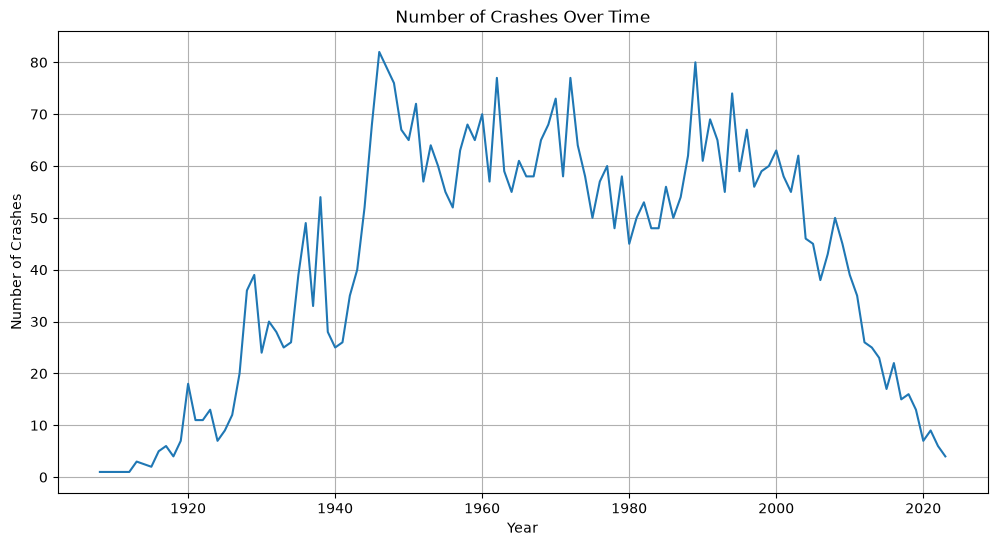

In [27]:
# Visualize how the number of crashes changes over time
plt.figure(figsize=(12, 6))
crashes_per_year.plot(kind="line")

plt.title("Number of Crashes Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.grid(True)
plt.show()

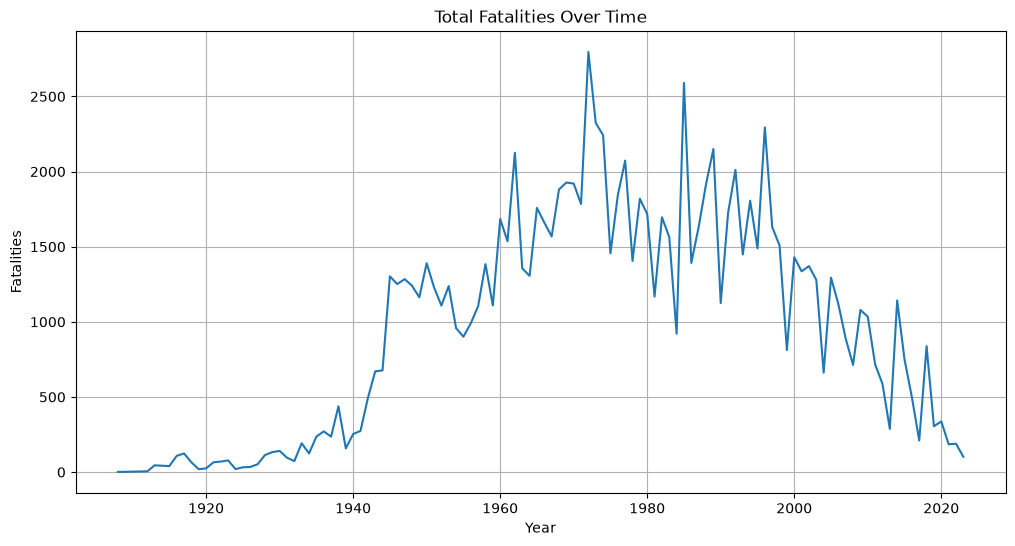

In [28]:
# Sum fatalities by year and plot the trend over time
fatalities_per_year = data.groupby("Year")["Fatalities"].sum()

plt.figure(figsize=(12, 6))
fatalities_per_year.plot(kind="line")

plt.title("Total Fatalities Over Time")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.grid(True)
plt.show()

In [29]:
# Create a yearly summary with crash counts, fatalities, and survival metrics
yearly_summary = data.groupby("Year").agg(
    Crashes=("Date", "count"),
    Fatalities=("Fatalities", "sum"),
    Aboard=("Aboard", "sum")
)

yearly_summary["Survivors"] = yearly_summary["Aboard"] - yearly_summary["Fatalities"]
yearly_summary["Survival_Rate"] = (
    yearly_summary["Survivors"] / yearly_summary["Aboard"]
) * 100

yearly_summary.head()

,Crashes,Fatalities,Aboard,Survivors,Survival_Rate
Year,,,,,
1908,1,1,2,1,50.000000
1912,1,5,5,0,0.000000
1913,3,45,51,6,11.764706
1915,2,40,60,20,33.333333
1916,5,108,109,1,0.917431


In [30]:
# Inspect the most recent rows of the yearly summary
yearly_summary.tail(20)

,Crashes,Fatalities,Aboard,Survivors,Survival_Rate
Year,,,,,
2004,46,662,877,215,24.515393
2005,45,1294,2151,857,39.841934
2006,38,1118,1374,256,18.631732
2007,43,888,1465,577,39.385666
2008,50,713,1348,635,47.106825
2009,45,1079,1613,534,33.106014
2010,39,1034,1451,417,28.738801
2011,35,717,981,264,26.911315
2012,26,587,695,108,15.539568


3. Statistical Analysis:

Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.

Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).

In [ ]:
# Summarize the distribution of fatalities with key descriptive statistics
fatalities = data["Fatalities"]

print("Fatalities statistics:")
print(f"Mean: {fatalities.mean():.2f}")
print(f"Median: {fatalities.median():.2f}")
print(f"Standard deviation: {fatalities.std():.2f}")
print(f"Skewness: {stats.skew(fatalities):.2f}")
print(f"Kurtosis: {stats.kurtosis(fatalities):.2f}")

Fatalities statistics:
Mean: 22.65
Median: 11.00
Standard deviation: 35.38
Skewness: 4.57
Kurtosis: 35.94


In [ ]:
# Summarize the distribution of survival rates with descriptive statistics
survival_rate = data["Survival_Rate"].dropna()

print("Survival rate statistics:")
print(f"Mean: {survival_rate.mean():.2f}")
print(f"Median: {survival_rate.median():.2f}")
print(f"Standard deviation: {survival_rate.std():.2f}")
print(f"Skewness: {stats.skew(survival_rate):.2f}")
print(f"Kurtosis: {stats.kurtosis(survival_rate):.2f}")

Survival rate statistics:
Mean: 18.29
Median: 0.00
Standard deviation: 31.32
Skewness: 1.54
Kurtosis: 0.86


In [ ]:
# Test whether the fatalities and survival-rate distributions are approximately normal
fatalities_normal_test = stats.normaltest(fatalities)
survival_normal_test = stats.normaltest(survival_rate)

print("Fatalities normality test:")
print(f"p-value: {fatalities_normal_test.pvalue:.2f}")

print("\nSurvival Rate normality test:")
print(f"p-value: {survival_normal_test.pvalue:.2f}")

Fatalities normality test:
p-value: 0.00

Survival Rate normality test:
p-value: 0.00


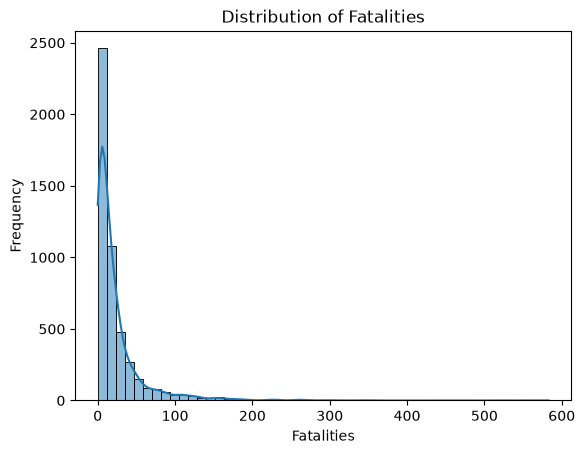

In [ ]:
# Plot the distribution of fatalities, including the density curve
sns.histplot(fatalities, bins=50, kde=True)
plt.title("Distribution of Fatalities")
plt.xlabel("Fatalities")
plt.ylabel("Frequency")
plt.show()

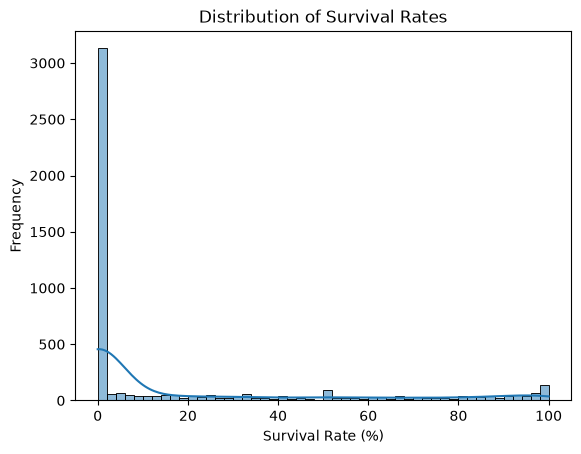

In [ ]:
# Plot the distribution of survival rates with a smooth density estimate
sns.histplot(survival_rate, bins=50, kde=True)
plt.title("Distribution of Survival Rates")
plt.xlabel("Survival Rate (%)")
plt.ylabel("Frequency")
plt.show()

4. Visualization:

Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.

Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.

Text(0.5, 1.0, 'Top 10 Locations by Total Fatalities')

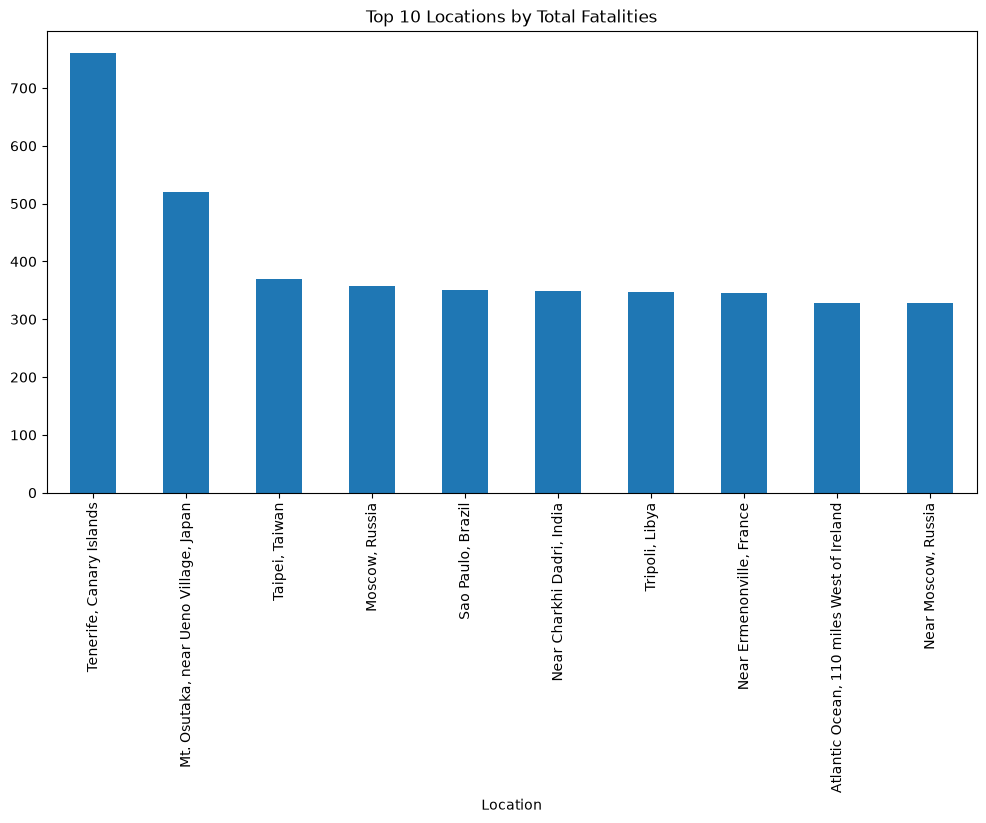

In [45]:
top10_locations = data.groupby("Location")["Fatalities"].sum().sort_values(ascending=False).head(10)
top10_locations.plot(kind="bar", figsize=(12, 6))
plt.title("Top 10 Locations by Total Fatalities")

<Axes: xlabel='Operator'>

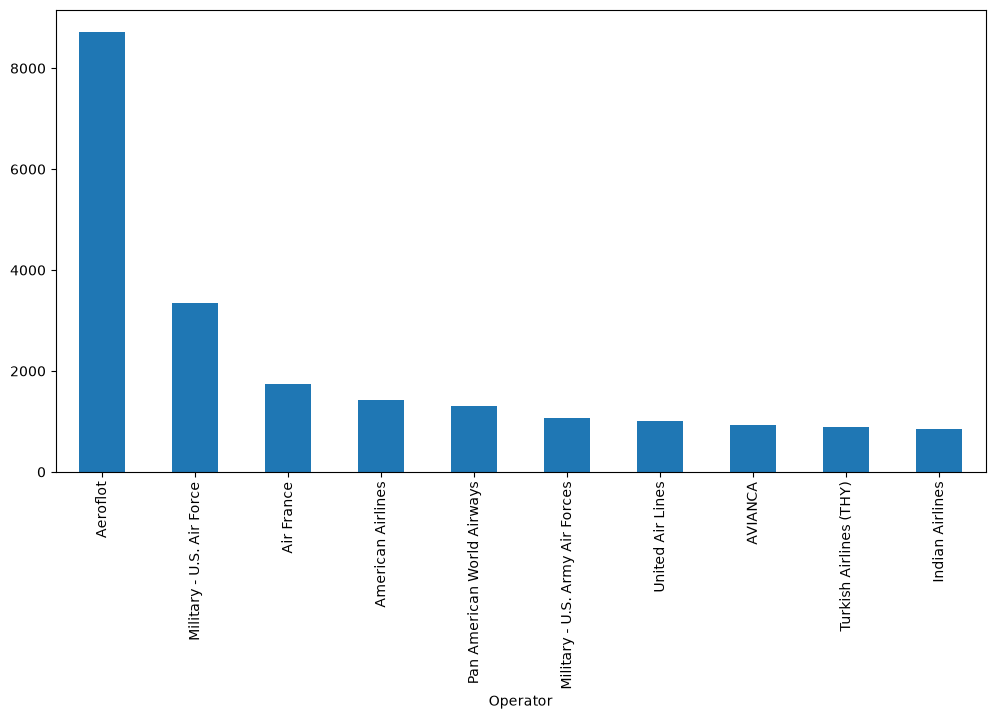

In [46]:
top10_operators = data.groupby("Operator")["Fatalities"].sum().sort_values(ascending=False).head(10)
top10_operators.plot(kind="bar", figsize=(12, 6))

<Axes: xlabel='AC Type'>

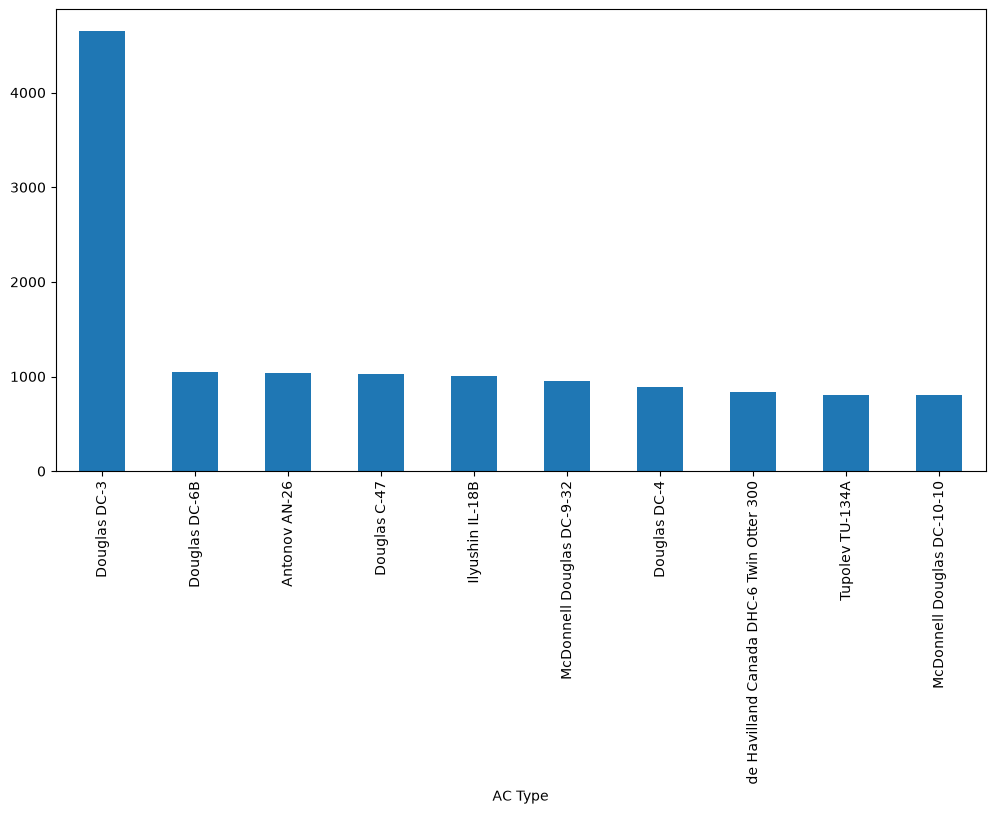

In [47]:
top10_AC_types = data.groupby("AC Type")["Fatalities"].sum().sort_values(ascending=False).head(10)
top10_AC_types.plot(kind="bar", figsize=(12, 6))

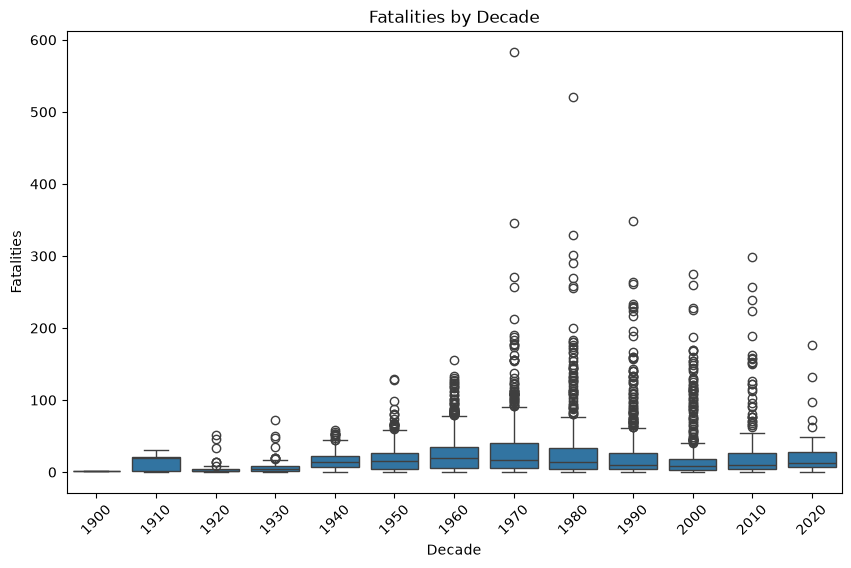

In [50]:
# Create a decade column from the Year column
data["Decade"] = (data["Year"] // 10) * 10

# Boxplot of fatalities by decade
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="Decade", y="Fatalities")
plt.title("Fatalities by Decade")
plt.xlabel("Decade")
plt.ylabel("Fatalities")
plt.xticks(rotation=45)
plt.show()

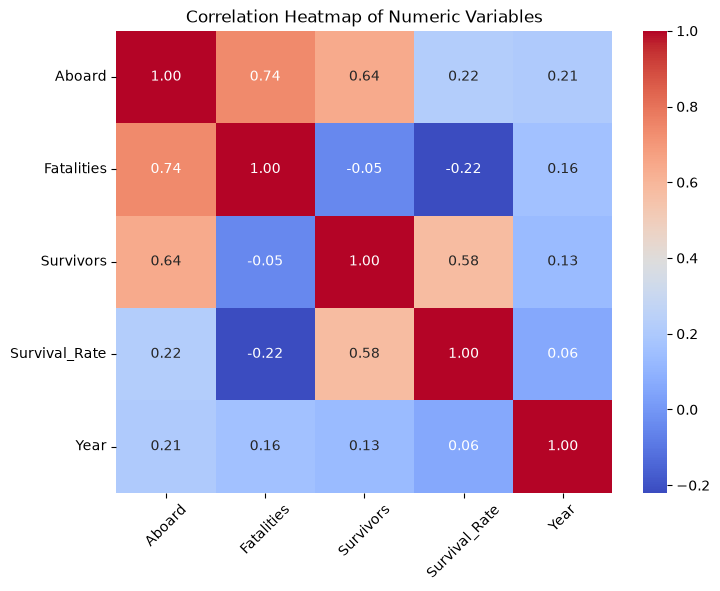

In [51]:
# Create a correlation heatmap for the main numeric variables
numeric_features = data[["Aboard", "Fatalities", "Survivors", "Survival_Rate", "Year"]]
correlation_matrix = numeric_features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## 5. Insights and Report

After cleaning the dataset, **4,876 airplane crashes** remained for analysis. These crashes involved **154,060 people**, with **110,423 fatalities** and **43,637 survivors**. The overall survival rate was approximately **28.32%**.

The graphs show that the number of recorded crashes changed greatly over time. The highest number of crashes occurred in **1946**, while the highest yearly number of fatalities occurred in **1972**. In general, fewer crashes were recorded in recent years.

The fatality distribution is strongly right-skewed. Most crashes had a relatively small number of fatalities, but a few major disasters had extremely high totals. The deadliest crash in the dataset was the **Tenerife disaster**, with **583 fatalities**.

There is also a strong positive relationship between the number of people aboard and the number of fatalities. This is expected because accidents involving larger aircraft can affect more people.

### Conclusion

The analysis suggests that recorded airplane crashes have generally decreased over time. However, rare major disasters can still cause very large numbers of fatalities. The results should be interpreted carefully because the dataset contains crash records only and does not include the total number of successful flights.
